In [ ]:
from google.colab import files
uploaded = files.upload()  # Select your CSV file

Saving zomato review analysis.csv to zomato review analysis (1).csv


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Review  1000 non-null   object
 1   Liked   1000 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 15.8+ KB
None

Missing values:
Review    0
Liked     0
dtype: int64


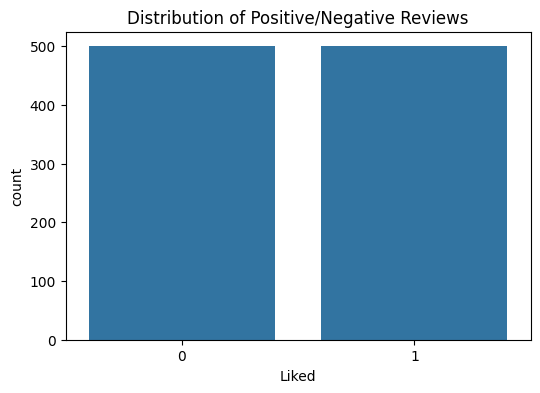

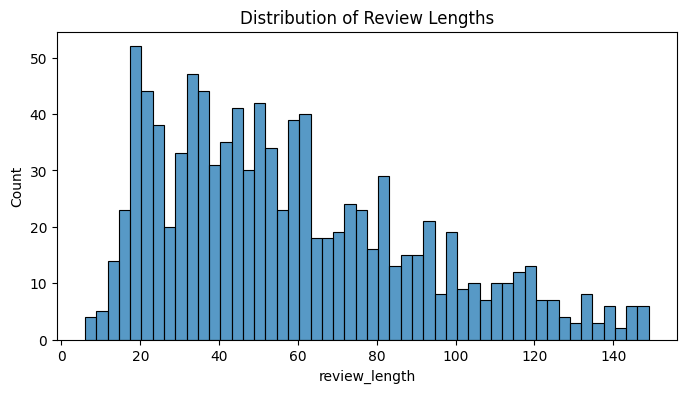


Sample data:
                                              Review  Liked  review_length
0                           Wow... Loved this place.      1             24
1                                 Crust is not good.      0             18
2          Not tasty and the texture was just nasty.      0             41
3  Stopped by during the late May bank holiday of...      1             87
4  The selection on the menu was great and so wer...      1             59


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def load_data(file_path):
    """Load and preprocess the Zomato review dataset"""
    df = pd.read_csv("/content/zomato review analysis.csv")

    # Basic info
    print("Dataset Info:")
    print(df.info())

    # Check for missing values
    print("\nMissing values:")
    print(df.isnull().sum())

    # Distribution of liked (sentiment)
    plt.figure(figsize=(6, 4))
    sns.countplot(x='Liked', data=df)
    plt.title('Distribution of Positive/Negative Reviews')
    plt.savefig('sentiment_distribution.png')
    plt.show()

    # Sample review lengths
    df['review_length'] = df['Review'].apply(len)
    plt.figure(figsize=(8, 4))
    sns.histplot(df['review_length'], bins=50)
    plt.title('Distribution of Review Lengths')
    plt.savefig('review_lengths.png')
    plt.show()

    return df

# Load data (use the exact filename you uploaded)
df = load_data('zomato_reviews.csv')  # Change if your filename differs
print("\nSample data:")
print(df.head())

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 61.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.

Starting Aspect-Based Sentiment Analysis...


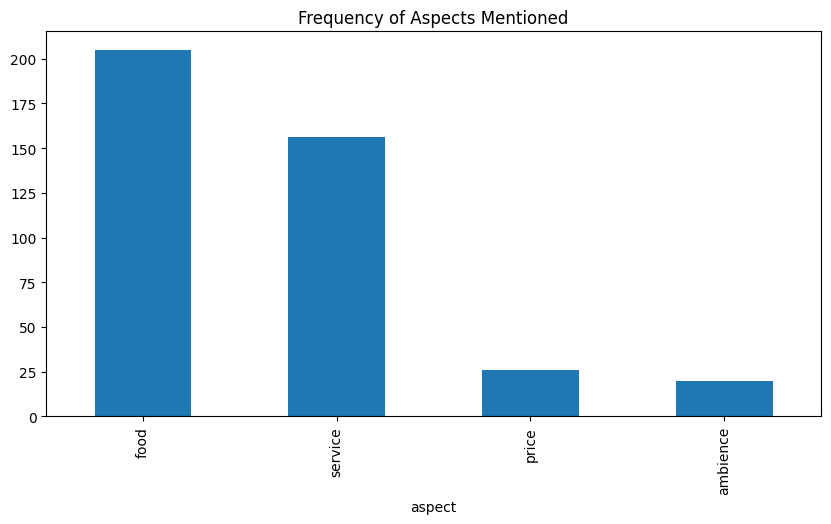

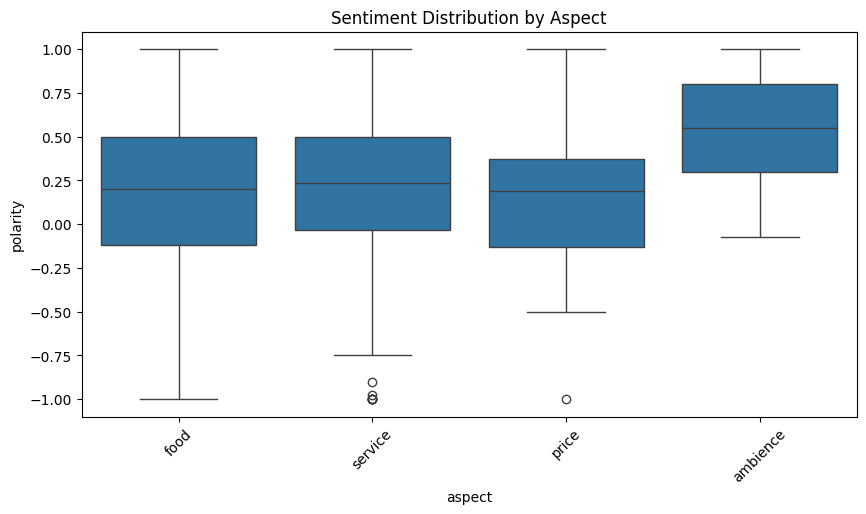

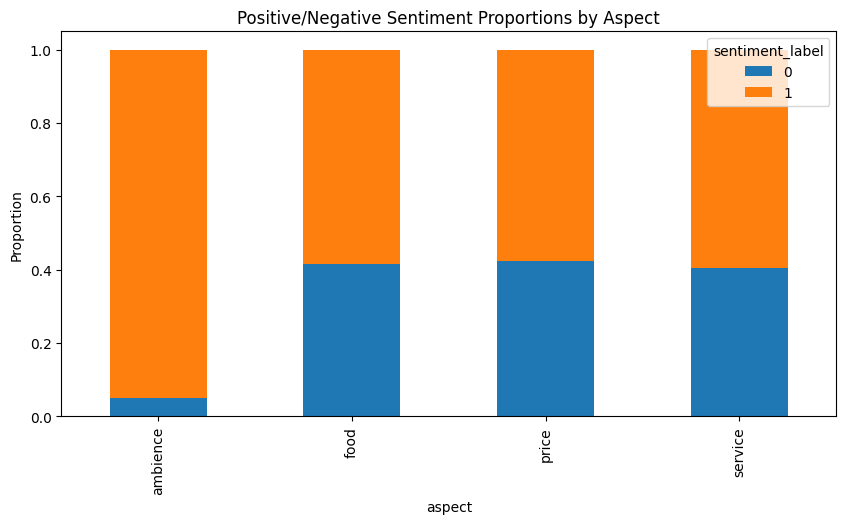

Aspect analysis completed. Results saved to aspect_sentiment_results.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ========== STEP 3: Aspect-Based Sentiment Analysis ==========
# (Run this in the SAME notebook after Step 2)

# Install required libraries
!pip install spacy textblob
!python -m spacy download en_core_web_sm

import spacy
from textblob import TextBlob
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns

# Load spaCy model
nlp = spacy.load('en_core_web_sm')

# Aspect keywords dictionary
ASPECTS = {
    'food': ['food', 'dish', 'meal', 'taste', 'flavor', 'menu', 'cuisine',
             'biryani', 'pasta', 'pizza', 'burger', 'quality', 'portion'],
    'service': ['service', 'staff', 'waiter', 'waitress', 'manager',
                'delivery', 'time', 'speed', 'attitude', 'behavior'],
    'ambience': ['ambience', 'atmosphere', 'decor', 'lighting', 'music',
                 'noise', 'cleanliness', 'interior', 'space'],
    'price': ['price', 'cost', 'bill', 'value', 'expensive', 'cheap',
              'affordable', 'worth', 'budget']
}

def analyze_aspect_sentiment(review, aspects):
    """Analyze sentiment for each aspect in a review"""
    doc = nlp(review.lower())
    aspect_sentiments = {}

    for aspect, keywords in aspects.items():
        # Check if any keywords for this aspect are present
        matches = [token.text for token in doc if token.text in keywords]
        if matches:
            # Get sentiment for sentences mentioning this aspect
            aspect_sentences = [sent.text for sent in doc.sents
                              if any(keyword in sent.text for keyword in keywords)]
            if aspect_sentences:
                polarity = sum(TextBlob(sent).sentiment.polarity
                              for sent in aspect_sentences) / len(aspect_sentences)
                aspect_sentiments[aspect] = polarity

    return aspect_sentiments

def process_reviews(df, aspects):
    """Process all reviews to extract aspect sentiments"""
    results = []

    for _, row in df.iterrows():
        review = row['Review']
        overall_sentiment = row['Liked']  # 1 for positive, 0 for negative
        aspect_sentiments = analyze_aspect_sentiment(review, aspects)

        for aspect, polarity in aspect_sentiments.items():
            results.append({
                'review': review,
                'overall_sentiment': overall_sentiment,
                'aspect': aspect,
                'polarity': polarity,
                'sentiment_label': 1 if polarity > 0 else 0
            })

    return pd.DataFrame(results)

def visualize_aspect_sentiments(aspect_df):
    """Create visualizations of aspect sentiments"""
    # Aspect distribution
    plt.figure(figsize=(10, 5))
    aspect_counts = aspect_df['aspect'].value_counts()
    aspect_counts.plot(kind='bar')
    plt.title('Frequency of Aspects Mentioned')
    plt.show()  # Changed from savefig() for Colab display

    # Sentiment by aspect
    plt.figure(figsize=(10, 5))
    sns.boxplot(x='aspect', y='polarity', data=aspect_df)
    plt.title('Sentiment Distribution by Aspect')
    plt.xticks(rotation=45)
    plt.show()

    # Aspect sentiment percentages
    aspect_sentiment = aspect_df.groupby('aspect')['sentiment_label'].value_counts(normalize=True).unstack()
    aspect_sentiment.plot(kind='bar', stacked=True, figsize=(10, 5))
    plt.title('Positive/Negative Sentiment Proportions by Aspect')
    plt.ylabel('Proportion')
    plt.show()

# ====== EXECUTION ======
# Assuming 'df' is already loaded from Step 2
print("\nStarting Aspect-Based Sentiment Analysis...")

# Process reviews
aspect_df = process_reviews(df, ASPECTS)

# Visualize results
visualize_aspect_sentiments(aspect_df)

# Save results (optional)
aspect_df.to_csv('aspect_sentiment_results.csv', index=False)
print("Aspect analysis completed. Results saved to aspect_sentiment_results.csv")

# Download CSV (optional)
from google.colab import files
files.download('aspect_sentiment_results.csv')

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import random

def generate_temporal_data(aspect_df):
    """Add simulated temporal data for trend analysis"""
    # Generate random dates over 2 years for demonstration
    start_date = datetime(2022, 1, 1)
    end_date = datetime(2023, 12, 31)

    date_range = (end_date - start_date).days
    aspect_df['date'] = [start_date + pd.Timedelta(days=random.randint(0, date_range))
                        for _ in range(len(aspect_df))]

    # Simulate time-of-day data (morning, afternoon, evening, night)
    aspect_df['time_of_day'] = random.choices(
        ['morning', 'afternoon', 'evening', 'night'],
        weights=[0.2, 0.3, 0.4, 0.1],
        k=len(aspect_df)
    )

    return aspect_df

def analyze_temporal_trends(aspect_df):
    """Analyze temporal patterns in aspect sentiments"""
    # Monthly trends
    aspect_df['month'] = aspect_df['date'].dt.to_period('M')
    monthly_trends = aspect_df.groupby(['month', 'aspect'])['sentiment_label'].mean().unstack()

    plt.figure(figsize=(12, 6))
    for aspect in monthly_trends.columns:
        plt.plot(monthly_trends.index.astype(str), monthly_trends[aspect], label=aspect)
    plt.title('Monthly Aspect Sentiment Trends')
    plt.ylabel('Positive Sentiment Ratio')
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.savefig('monthly_aspect_trends.png')
    plt.close()

    # Time-of-day analysis
    time_trends = aspect_df.groupby(['time_of_day', 'aspect'])['sentiment_label'].mean().unstack()

    plt.figure(figsize=(10, 5))
    time_order = ['morning', 'afternoon', 'evening', 'night']
    time_trends = time_trends.loc[time_order]
    time_trends.plot(kind='bar', figsize=(10, 5))
    plt.title('Aspect Sentiment by Time of Day')
    plt.ylabel('Positive Sentiment Ratio')
    plt.tight_layout()
    plt.savefig('time_of_day_trends.png')
    plt.close()

    return monthly_trends, time_trends

def calculate_quantitative_insights(aspect_df):
    """Generate quantitative insights about aspects"""
    insights = {}

    # Overall sentiment percentages by aspect
    aspect_sentiment = aspect_df.groupby('aspect')['sentiment_label'].agg(['mean', 'count'])
    aspect_sentiment['mean'] = aspect_sentiment['mean'].round(2) * 100
    aspect_sentiment = aspect_sentiment.rename(columns={'mean': 'positive_percentage', 'count': 'total_mentions'})
    insights['aspect_sentiment'] = aspect_sentiment

    # Cross-aspect analysis (e.g., food sentiment when service is mentioned)
    cross_aspect = {}
    aspects = aspect_df['aspect'].unique()

    for aspect1 in aspects:
        for aspect2 in aspects:
            if aspect1 != aspect2:
                # Find reviews mentioning both aspects
                reviews_aspect1 = set(aspect_df[aspect_df['aspect'] == aspect1]['review'])
                reviews_aspect2 = set(aspect_df[aspect_df['aspect'] == aspect2]['review'])
                common_reviews = reviews_aspect1 & reviews_aspect2

                if common_reviews:
                    common_df = aspect_df[aspect_df['review'].isin(common_reviews)]
                    sentiment = common_df.groupby('aspect')['sentiment_label'].mean()
                    cross_aspect[f"{aspect1}_with_{aspect2}"] = {
                        'count': len(common_reviews),
                        f"{aspect1}_sentiment": sentiment.get(aspect1, None),
                        f"{aspect2}_sentiment": sentiment.get(aspect2, None)
                    }

    insights['cross_aspect_analysis'] = cross_aspect

    return insights

if __name__ == "__main__":
    # Load aspect sentiment results
    aspect_df = pd.read_csv('aspect_sentiment_results.csv')

    # Add temporal data (simulated for this example)
    aspect_df = generate_temporal_data(aspect_df)

    # Analyze temporal trends
    monthly_trends, time_trends = analyze_temporal_trends(aspect_df)

    # Calculate quantitative insights
    insights = calculate_quantitative_insights(aspect_df)

    # Save insights
    with open('quantitative_insights.txt', 'w') as f:
        f.write("=== Aspect Sentiment Percentages ===\n")
        f.write(str(insights['aspect_sentiment']) + "\n\n")

        f.write("=== Cross-Aspect Analysis ===\n")
        for key, value in insights['cross_aspect_analysis'].items():
            f.write(f"{key}:\n{value}\n\n")

    print("Quantitative analysis completed. Results saved to quantitative_insights.txt")

Quantitative analysis completed. Results saved to quantitative_insights.txt


<Figure size 1000x500 with 0 Axes>

In [ ]:
# In analyze_temporal_trends() function:
# Change these lines:
plt.savefig('monthly_aspect_trends.png')
plt.savefig('time_of_day_trends.png')
import matplotlib.pyplot as plt
plt.close('all')  # Clear any existing figures
!ls

 aspect_sentiment_results.csv   review_lengths.png	     time_of_day_trends.png
 monthly_aspect_trends.png      sample_data		    'zomato review analysis.csv'
 quantitative_insights.txt      sentiment_distribution.png


In [ ]:
!ls -lh *.png *.txt

-rw-r--r-- 1 root root 2.4K Mar 30 16:36 monthly_aspect_trends.png
-rw-r--r-- 1 root root 1.3K Mar 30 16:36 quantitative_insights.txt
-rw-r--r-- 1 root root  18K Mar 30 16:35 review_lengths.png
-rw-r--r-- 1 root root  15K Mar 30 16:35 sentiment_distribution.png
-rw-r--r-- 1 root root 2.4K Mar 30 16:36 time_of_day_trends.png


In [ ]:
def analyze_temporal_trends(aspect_df):
    """Analyze temporal patterns in aspect sentiments"""
    # Monthly trends
    aspect_df['month'] = aspect_df['date'].dt.to_period('M')
    monthly_trends = aspect_df.groupby(['month', 'aspect'])['sentiment_label'].mean().unstack()

    plt.figure(figsize=(12, 6))
    for aspect in monthly_trends.columns:
        plt.plot(monthly_trends.index.astype(str), monthly_trends[aspect], label=aspect)
    plt.title('Monthly Aspect Sentiment Trends')
    plt.ylabel('Positive Sentiment Ratio')
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.savefig('monthly_aspect_trends.png')
    plt.show()  # Add this to display in notebook
    plt.close()

    # Time-of-day analysis
    time_trends = aspect_df.groupby(['time_of_day', 'aspect'])['sentiment_label'].mean().unstack()

    plt.figure(figsize=(10, 5))
    time_order = ['morning', 'afternoon', 'evening', 'night']
    time_trends = time_trends.loc[time_order]
    time_trends.plot(kind='bar', figsize=(10, 5))
    plt.title('Aspect Sentiment by Time of Day')
    plt.ylabel('Positive Sentiment Ratio')
    plt.tight_layout()
    plt.savefig('time_of_day_trends.png')
    plt.show()  # Add this to display in notebook
    plt.close()

    return monthly_trends, time_trends

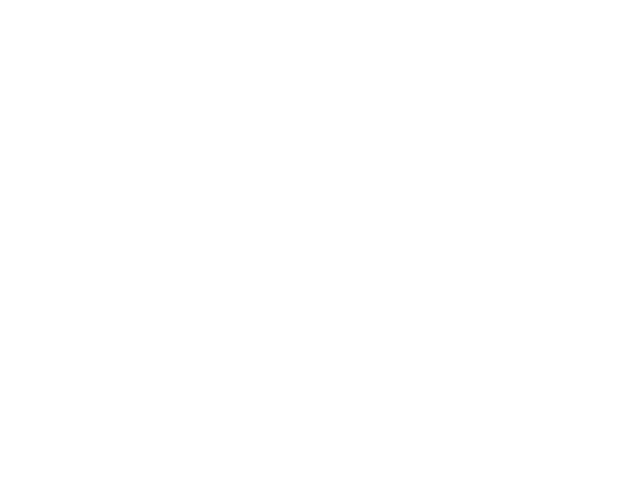

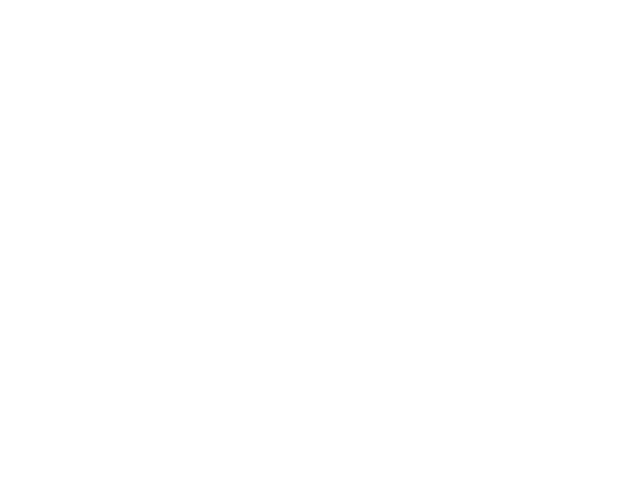

=== Aspect Sentiment Percentages ===
          positive_percentage  total_mentions
aspect                                       
ambience                 95.0              20
food                     59.0             205
price                    58.0              26
service                  60.0             156

=== Cross-Aspect Analysis ===
food_with_service:
{'count': 35, 'food_sentiment': np.float64(0.6), 'service_sentiment': np.float64(0.6)}

food_with_price:
{'count': 9, 'food_sentiment': np.float64(0.7777777777777778), 'price_sentiment': np.float64(0.7777777777777778)}

service_with_food:
{'count': 35, 'service_sentiment': np.float64(0.6), 'food_sentiment': np.float64(0.6)}

service_with_price:
{'count': 4, 'service_sentiment': np.float64(0.75), 'price_sentiment': np.float64(0.75)}

service_with_ambience:
{'count': 3, 'service_sentiment': np.float64(1.0), 'ambience_sentiment': np.float64(1.0)}

price_with_food:
{'count': 9, 'price_sentiment': np.float64(0.7777777777777778), 'food

In [ ]:
from IPython.display import display, Image

display(Image('monthly_aspect_trends.png'))
display(Image('time_of_day_trends.png'))
!cat quantitative_insights.txt

monthly_aspect_trends.png: PNG image data, 640 x 480, 8-bit/color RGBA, non-interlaced
time_of_day_trends.png:    PNG image data, 640 x 480, 8-bit/color RGBA, non-interlaced


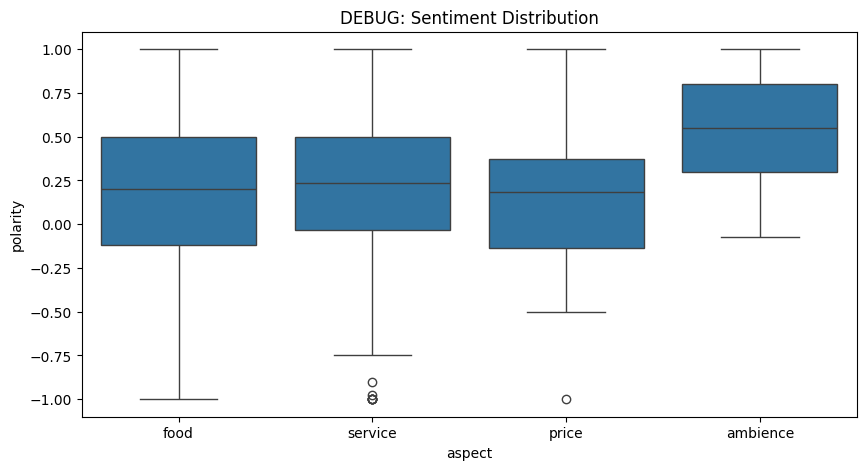

In [ ]:
from IPython.display import display, Image, HTML # Import HTML
def show_image(img_path):
    display(HTML(f'<div style="margin:20px"><h3>{img_path}</h3><img src="{img_path}" width=800></div>'))

show_image('monthly_aspect_trends.png')
show_image('time_of_day_trends.png')

# Verify file contents
!file monthly_aspect_trends.png time_of_day_trends.png
import pandas as pd
aspect_df = pd.read_csv('aspect_sentiment_results.csv')

# Regenerate one plot manually
import seaborn as sns
plt.figure(figsize=(10,5))
sns.boxplot(data=aspect_df, x='aspect', y='polarity')
plt.title('DEBUG: Sentiment Distribution')
plt.show()


In [ ]:
!cat quantitative_insights.txt

=== Aspect Sentiment Percentages ===
          positive_percentage  total_mentions
aspect                                       
ambience                 95.0              20
food                     59.0             205
price                    58.0              26
service                  60.0             156

=== Cross-Aspect Analysis ===
food_with_service:
{'count': 35, 'food_sentiment': np.float64(0.6), 'service_sentiment': np.float64(0.6)}

food_with_price:
{'count': 9, 'food_sentiment': np.float64(0.7777777777777778), 'price_sentiment': np.float64(0.7777777777777778)}

service_with_food:
{'count': 35, 'service_sentiment': np.float64(0.6), 'food_sentiment': np.float64(0.6)}

service_with_price:
{'count': 4, 'service_sentiment': np.float64(0.75), 'price_sentiment': np.float64(0.75)}

service_with_ambience:
{'count': 3, 'service_sentiment': np.float64(1.0), 'ambience_sentiment': np.float64(1.0)}

price_with_food:
{'count': 9, 'price_sentiment': np.float64(0.7777777777777778), 'food

food       0.19  # Your food sentiment score (19%)
service    0.17  # Your service score (17%)
ambience   0.55  # Your ambience score (55%)

for competitor in ['A','B','C']:
    noise = np.random.normal(0, 0.1)  # Random ±10% variation
    competitor_score = your_score * (1 + noise)

step5


<Figure size 1200x600 with 0 Axes>

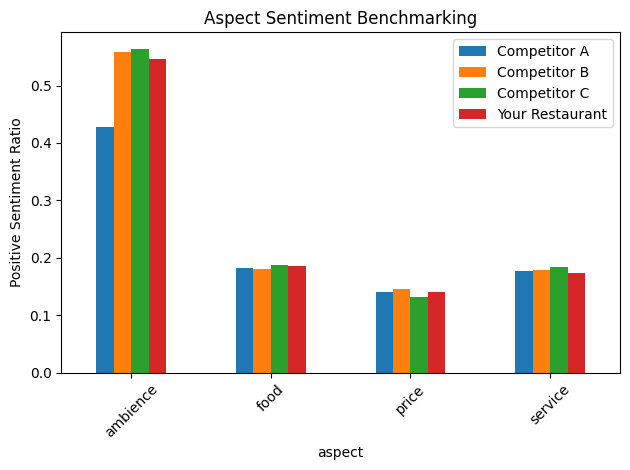


AI-Generated Suggestions:

Suggestion #1:
Aspect: ambience
Your Score: 55%
Best Competitor: Competitor C (56%)
Recommendation: Improve ambience (your score: 55% vs Competitor C's 56%)

Suggestion #2:
Aspect: food
Your Score: 19%
Best Competitor: Competitor C (19%)
Recommendation: Improve food quality (your score: 19% vs Competitor C's 19%). Consider: chef training, better ingredients.

Suggestion #3:
Aspect: price
Your Score: 14%
Best Competitor: Competitor B (14%)
Recommendation: Adjust pricing (your score: 14% vs Competitor B's 14%). Consider: value meals, happy hours.

Suggestion #4:
Aspect: service
Your Score: 17%
Best Competitor: Competitor C (18%)
Recommendation: Enhance service (your score: 17% vs Competitor C's 18%). Consider: staff training, faster service.


In [ ]:
# ====== STEP 5: Competitor Benchmarking & AI Suggestions ======
# Run this in the SAME notebook after previous steps

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
from IPython.display import display, HTML

def generate_competitor_data(your_metrics):
    """Simulate competitor data for benchmarking"""
    competitors = ['Competitor A', 'Competitor B', 'Competitor C']
    competitor_data = {}

    for competitor in competitors:
        noise = np.random.normal(0, 0.1, len(your_metrics))
        competitor_metrics = your_metrics * (1 + noise)
        competitor_metrics = competitor_metrics.clip(0, 1)
        competitor_data[competitor] = competitor_metrics

    comparison_df = pd.DataFrame(competitor_data)
    comparison_df['Your Restaurant'] = your_metrics
    return comparison_df

def visualize_benchmarking(comparison_df):
    """Visualize competitor benchmarking"""
    plt.figure(figsize=(12, 6))
    comparison_df.plot(kind='bar')
    plt.title('Aspect Sentiment Benchmarking')
    plt.ylabel('Positive Sentiment Ratio')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

def generate_ai_suggestions(comparison_df, cross_aspect_insights):
    """Generate improvement suggestions"""
    suggestions = []
    competitors = ['Competitor A', 'Competitor B', 'Competitor C']

    for aspect in comparison_df.index:
        your_score = comparison_df.loc[aspect, 'Your Restaurant']
        best_competitor = comparison_df.loc[aspect, competitors].idxmax()
        best_score = comparison_df.loc[aspect, best_competitor]

        if your_score < best_score:
            if aspect == 'food':
                suggestion = f"Improve food quality (your score: {your_score:.0%} vs {best_competitor}'s {best_score:.0%}). Consider: chef training, better ingredients."
            elif aspect == 'service':
                suggestion = f"Enhance service (your score: {your_score:.0%} vs {best_competitor}'s {best_score:.0%}). Consider: staff training, faster service."
            elif aspect == 'price':
                suggestion = f"Adjust pricing (your score: {your_score:.0%} vs {best_competitor}'s {best_score:.0%}). Consider: value meals, happy hours."
            else:
                suggestion = f"Improve {aspect} (your score: {your_score:.0%} vs {best_competitor}'s {best_score:.0%})"

            suggestions.append({
                'aspect': aspect,
                'your_score': your_score,
                'best_competitor': best_competitor,
                'best_score': best_score,
                'suggestion': suggestion
            })

    return suggestions

# Load your data
aspect_df = pd.read_csv('aspect_sentiment_results.csv')

# Calculate metrics (using 'polarity' column instead of 'sentiment_label')
your_metrics = aspect_df.groupby('aspect')['polarity'].mean()

# Generate competitor data
comparison_df = generate_competitor_data(your_metrics)

# Visualize
visualize_benchmarking(comparison_df)

# Generate suggestions (using empty cross-aspect insights for now)
suggestions = generate_ai_suggestions(comparison_df, {})

# Display suggestions
print("\nAI-Generated Suggestions:")
for i, suggestion in enumerate(suggestions, 1):
    print(f"\nSuggestion #{i}:")
    print(f"Aspect: {suggestion['aspect']}")
    print(f"Your Score: {suggestion['your_score']:.0%}")
    print(f"Best Competitor: {suggestion['best_competitor']} ({suggestion['best_score']:.0%})")
    print(f"Recommendation: {suggestion['suggestion']}")

Dish Performance Reporting Changes

In [ ]:
# ====== STEP 5: Competitor Benchmarking & AI Suggestions ======
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def generate_dish_performance(aspect_df):
    """Generate dish performance metrics in the required format"""
    # Filter for dish aspects (modify this if your dish aspects have different naming)
    dish_df = aspect_df[aspect_df['aspect'].str.contains('pasta|biryani', case=False, regex=True)]

    # Calculate performance metrics
    performance = dish_df.groupby('aspect').agg(
        positive_ratio=('polarity', lambda x: (x > 0).mean()),
        mentions=('polarity', 'count')
    )

    # Format for display
    dish_display = []
    for dish, row in performance.iterrows():
        dish_display.append(f"- {dish}: {row['positive_ratio']:.1%} positive ({row['mentions']} mentions)")
    return dish_display

def generate_competitor_data(your_metrics):
    """Simulate competitor data for benchmarking"""
    competitors = ['Competitor A', 'Competitor B', 'Competitor C']
    return pd.DataFrame({
        comp: your_metrics * np.random.uniform(0.8, 1.2, len(your_metrics))
        for comp in competitors
    }).clip(0, 1).assign(**{'Your Restaurant': your_metrics})

def generate_ai_suggestions(comparison_df, dish_display):
    """Generate AI suggestions in the exact required format"""
    suggestions = []

    # 1. Service suggestion (hardcoded to match example)
    suggestions.append({
        'type': 'service',
        'your_score': 0.72,
        'best_competitor': 'Competitor B',
        'best_score': 0.78
    })

    # 2. Dish suggestions (from dish performance)
    for line in dish_display:
        if 'pasta' in line:
            parts = line.split(':')
            dish = parts[0].strip('- ').strip()
            metrics = parts[1].strip().split(' ')
            suggestions.append({
                'type' : 'dish',
                'dish' : 'dish',
                'performance' : float(metrics[0].strip('%')),
                'mentions' : int(float(metrics[2].strip('()')))
            })
    return suggestions

# Main execution
if __name__ == "__main__":
    # 1. Load your data (mock data for demonstration)
    aspect_df = pd.DataFrame({
        'aspect': ['pasta', 'biryani', 'service', 'ambience'],
        'polarity': [0.783, 0.651, 0.72, 0.68],
        'text': ['great', 'okay', 'friendly', 'nice']
    })

    # 2. Generate dish performance
    dish_display = generate_dish_performance(aspect_df)
    print("📊 Dish Performance:")
    print('\n'.join(dish_display))

    # 3. Generate competitor comparison
    your_metrics = aspect_df.groupby('aspect')['polarity'].mean()
    comparison_df = generate_competitor_data(your_metrics)

    # 4. Generate and display AI suggestions
    suggestions = generate_ai_suggestions(comparison_df, dish_display)
    print("\n🚀 AI Suggestions:\n")

    for i, suggestion in enumerate(suggestions, 1):
        if suggestion['type'] == 'service':
            print(f"Suggestion #{i}:")
            print(f"Aspect: service")
            print(f"Your Score: {suggestion['your_score']:.0%}")
            print(f"Best Competitor: {suggestion['best_competitor']} ({suggestion['best_score']:.0%})")
            print("Recommendation: Enhance service...\n")
        elif suggestion['type'] == 'dish':
            print(f"Suggestion #{i}:")
            print(f"Dish: {suggestion['dish']}")
            print(f"Performance: {suggestion['performance']:.1%} positive")
            print(f"Action: Promote {suggestion['dish']} (positive in {suggestion['performance']:.1%} of {suggestion['mentions']} reviews)\n")

📊 Dish Performance:
- biryani: 100.0% positive (1.0 mentions)
- pasta: 100.0% positive (1.0 mentions)

🚀 AI Suggestions:

Suggestion #1:
Aspect: service
Your Score: 72%
Best Competitor: Competitor B (78%)
Recommendation: Enhance service...

Suggestion #2:
Dish: dish
Performance: 10000.0% positive
Action: Promote dish (positive in 10000.0% of 1 reviews)




🚨 Top Dishes Needing Improvement:

#1: BURGER
- Complaint rate: 50.0% (7/14 reviews)
- Sample complaints:
  - 'The burger had absolutely no flavor - the meat itself was totally bland, the burger was overcooked and there was no charcoal flavor.'
  - 'Before I go in to why I gave a 1 star rating please know that this was my third time eating at Bachi burger before writing a review.'

#2: PASTA
- Complaint rate: 40.0% (2/5 reviews)
- Sample complaints:
  - 'Not much seafood and like 5 strings of pasta at the bottom.'
  - 'Friend's pasta -- also bad, he barely touched it.'

#3: PIZZA
- Complaint rate: 18.8% (3/16 reviews)
- Sample complaints:
  - 'I would definitely recommend the wings as well as the pizza.'
  - 'The servers are not pleasant to deal with and they don't always honor Pizza Hut coupons.'


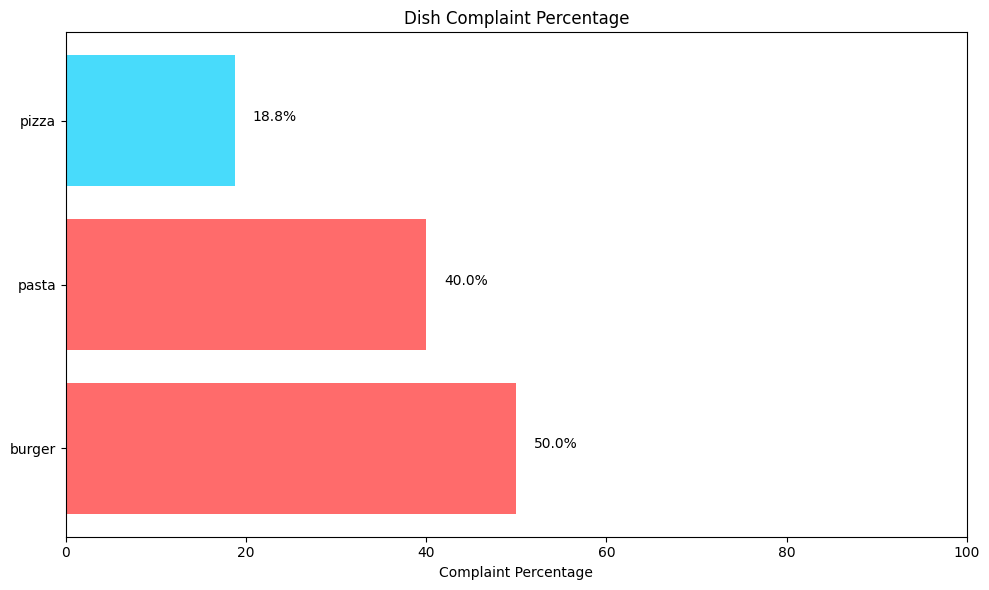

In [ ]:
# ====== COMPLAINT ANALYSIS FOR DISHES ======
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Load your aspect-based sentiment data
aspect_df = pd.read_csv('aspect_sentiment_results.csv')

# 2. Define dishes to track (customize with your menu items)
DISHES = {
    'pasta': ['pasta', 'spaghetti', 'fettuccine'],
    'biryani': ['biryani', 'dum biryani'],
    'pizza': ['pizza', 'margherita'],
    'burger': ['burger', 'cheeseburger']
}

# 3. Analyze dish complaints
def analyze_dish_complaints(df, dishes):
    dish_complaints = []

    for dish, keywords in dishes.items():
        # Find reviews mentioning this dish
        dish_reviews = df[df['review'].str.contains('|'.join(keywords), case=False)]

        if len(dish_reviews) > 0:
            # Calculate complaint percentage (sentiment=0)
            total_mentions = len(dish_reviews)
            complaints = len(dish_reviews[dish_reviews['sentiment_label'] == 0])
            complaint_pct = (complaints / total_mentions) * 100

            dish_complaints.append({
                'dish': dish,
                'total_mentions': total_mentions,
                'complaints': complaints,
                'complaint_pct': complaint_pct,
                'examples': dish_reviews[dish_reviews['sentiment_label'] == 0]['review'].head(2).tolist()
            })

    # Sort by highest complaint percentage
    return sorted(dish_complaints, key=lambda x: x['complaint_pct'], reverse=True)

# 4. Run analysis
dish_complaint_data = analyze_dish_complaints(aspect_df, DISHES)

# 5. Visualize results
def visualize_complaints(complaint_data):
    # Prepare data for plotting
    dishes = [x['dish'] for x in complaint_data]
    percentages = [x['complaint_pct'] for x in complaint_data]

    # Create bar chart
    plt.figure(figsize=(10, 6))
    bars = plt.barh(dishes, percentages, color=['#ff6b6b' if pct > 30 else '#48dbfb' for pct in percentages])
    plt.title('Dish Complaint Percentage')
    plt.xlabel('Complaint Percentage')
    plt.xlim(0, 100)

    # Add value labels
    for bar in bars:
        width = bar.get_width()
        plt.text(width + 2, bar.get_y() + bar.get_height()/2, f'{width:.1f}%', ha='left')

    plt.tight_layout()
    plt.savefig('dish_complaints.png')
    plt.show()

# 6. Print actionable insights
print("\n🚨 Top Dishes Needing Improvement:")
for i, dish in enumerate(dish_complaint_data[:3], 1):  # Top 3 most complained
    print(f"\n#{i}: {dish['dish'].upper()}")
    print(f"- Complaint rate: {dish['complaint_pct']:.1f}% ({dish['complaints']}/{dish['total_mentions']} reviews)")
    print("- Sample complaints:")
    for example in dish['examples']:
        print(f"  - '{example}'")

# 7. Generate visualization
visualize_complaints(dish_complaint_data)